# 🧠🤖 Classificadores MLP - Identificação de Doenças em Folhas

Nesta tarefa, você irá treinar um classificador de imagens pra identificar doenças em folhas de feijão usando o dataset `marquis03/bean-leaf-lesions-classification` disponível no [Kaggle](https://kaggle.com/datasets/). O dataset contém imagens de folhas saudáveis, com lesões do tipo *angular leaf spot* e *bean rust*. Abaixo, exemplos de cada tipo são ilustradas.


**Healthy** 

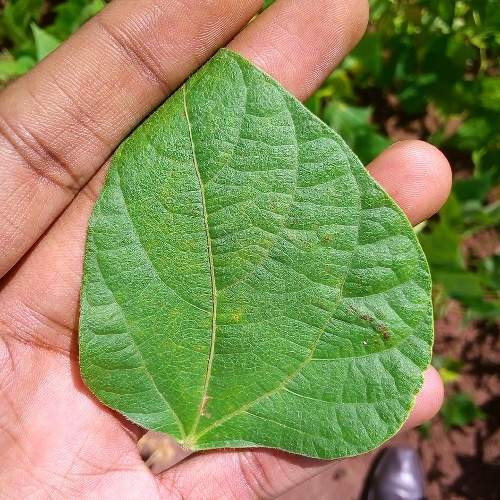

**Angular leaf spot**

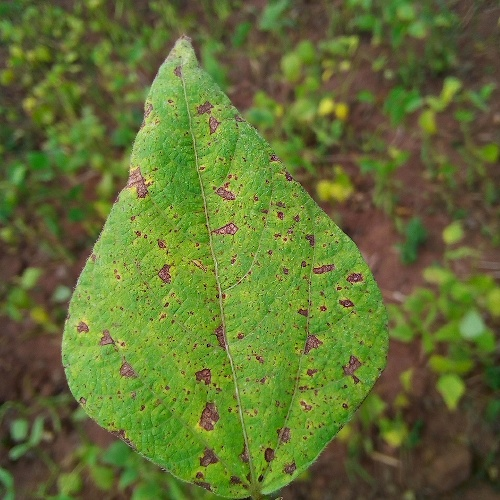

**Bean Rust**

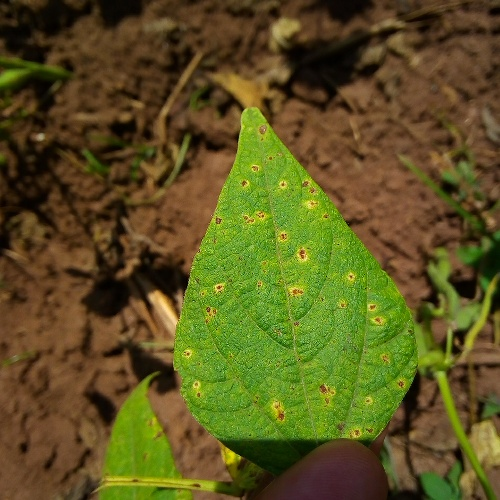

---

## Download e Exploração da Base de Dados

A base de dados que vamos utilizar é a [Bean Leaf Lesions Classification disponível no kaggle](https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification). Vamos utilizar a biblioteca `kagglehub` para fazer o download do dataset. 

O identificador de um dataset do kaggle é dado pelo nome do usuário que criou o dataset seguido do nome do dataset. No nosso caso, como a URL do dataset é `https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification` o nome do dataset será `marquis03/bean-leaf-lesions-classification` . 

Use a função `kagglehub.download_dataset`  para fazer o download do dataset e obter a pasta onde ele foi baixado.

In [1]:
from time import sleep

# resposta
import kagglehub

# ds_path é a pasta onde o dataset foi baixado
ds_path = kagglehub.dataset_download("marquis03/bean-leaf-lesions-classification")  # <<ADICIONE O IDENTIFICADOR AQUI
ds_path

/home/Heitor-Guerra/IdeaProjects/Redes_Neurais/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 155M/155M [00:06<00:00, 25.2MB/s] 

Extracting files...


'/home/Heitor-Guerra/.cache/kagglehub/datasets/marquis03/bean-leaf-lesions-classification/versions/1'

Cada dataset é armazenado em conjuntos específicos de arquivos e, infelizmente, não existe um padrão. 

O dataset **Bean Leaf Lesions Classification** contém os seguintes arquivos:

- `classname.txt`: nomes das classes
- `train/` : diretório contendo imagens de treino.
- `val/ `: diretório contendo imagens de validação. 
- `train.csv`: classes para cada imagem.
- `val.csv`: classes para cada imagem.

A célula abaixo utiliza a função `read_csv` da biblioteca `pandas` para ler os arquivos `.csv` . Em seguida, os dados são transformados em arrays do numpy. Como não foi disponibilizado um conjunto de teste, vamos usar os dados de validação como teste neste exemplo. Por simplicidade, não vamos utilizar um conjunto de validação neste exemplo. 

In [2]:
import os
import numpy as np
import pandas as pd

train_data = pd.read_csv(os.path.join(ds_path, 'train.csv')).to_numpy()
test_data = pd.read_csv(os.path.join(ds_path, 'val.csv')).to_numpy()

print("train_data.shape:", train_data.shape)
print("test_data.shape:", test_data.shape)


train_data.shape: (1034, 2)
test_data.shape: (133, 2)


Nos arrays de treino e teste, o número de linhas é o número de amostras no dataset e o existem duas colunas, a primeira contendo o nome do arquivo e a segunda contendo a classe. 

In [3]:
print("first rows:")
print(train_data[:5])

first rows:
[['train/healthy/healthy_train.98.jpg' 0]
 ['train/healthy/healthy_train.148.jpg' 0]
 ['train/healthy/healthy_train.306.jpg' 0]
 ['train/healthy/healthy_train.305.jpg' 0]
 ['train/healthy/healthy_train.40.jpg' 0]]


Como pode ser visto na figura abaixo, o conjunto de treino é balanceado com aproximadamente a mesma quantidade de amostras em cada classe.

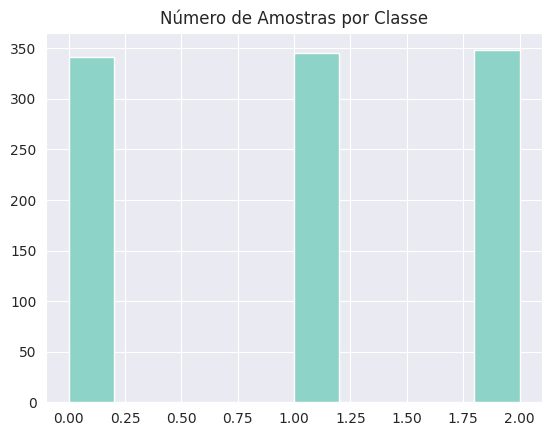

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

plt.hist(train_data[:, 1])
plt.title("Número de Amostras por Classe")
plt.show()

A célula abaixo mostra algumas imagens de exemplo do dataset. 

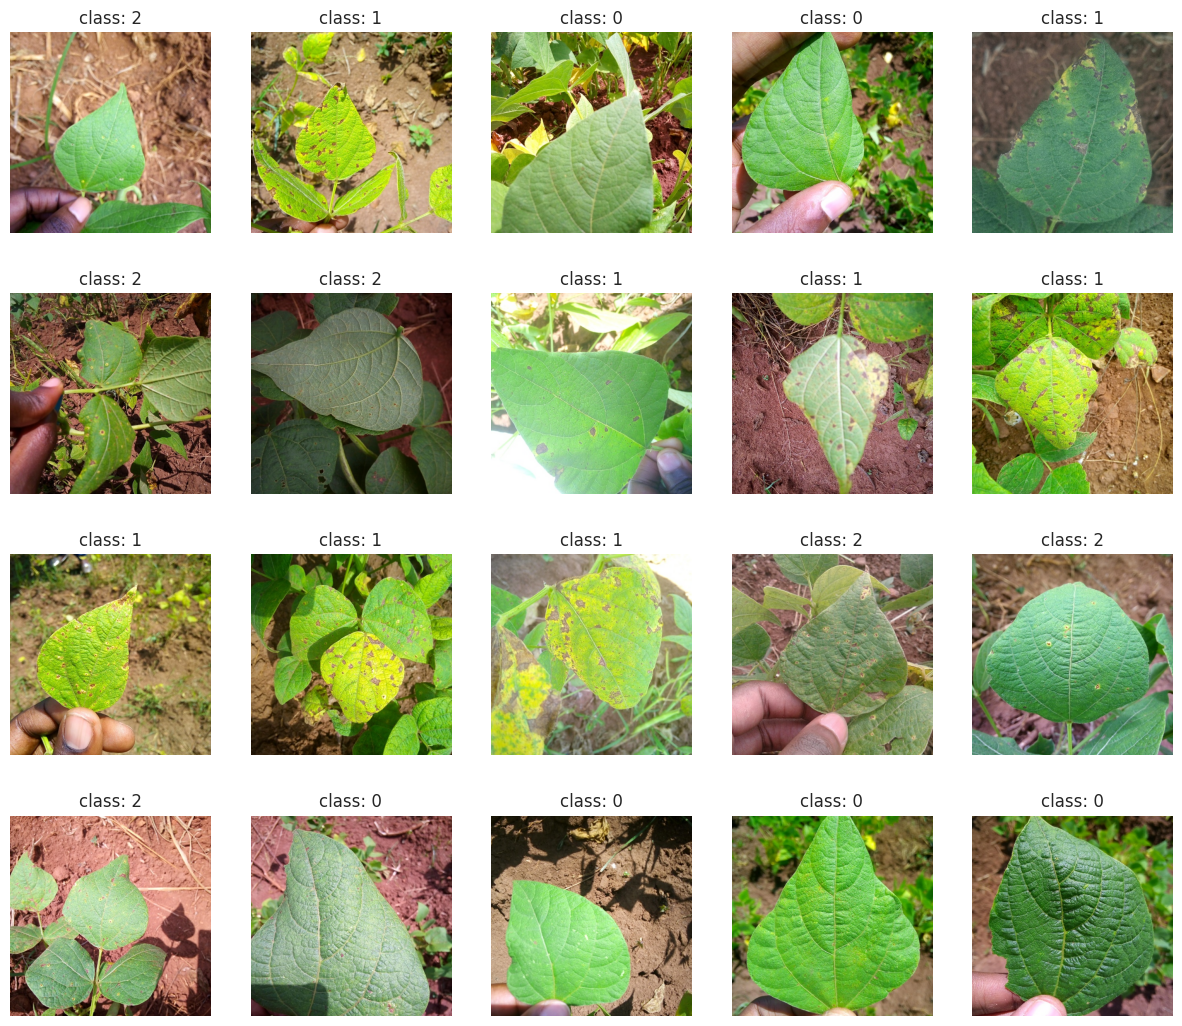

In [5]:
from PIL import Image

plt.figure(figsize=(15, 13))
for idx in range(20):
  random_idx = np.random.randint(0, len(train_data)-1)
  path, label = train_data[random_idx, :]
  image = Image.open(os.path.join(ds_path, path))
  plt.subplot(4, 5, idx+1)
  plt.imshow(image)
  plt.grid(False)
  plt.axis('off')
  plt.title(f"class: {label}")

plt.show()


---

## Treinamento e Avaliação do Modelo

Crie uma classe que herda de `torch.data.Dataset` e implementa os métodos: 
- `construtor`: recebe os dados baixados do kaggle.
- `__len__`: retorna o número de amostras.
- `__getitem__`: retorna a i-ésima imagem e o respectivo label como `torch.tensor`. Nesta função, você deve:
  -  carregar a imagem do disco usando PIL ou opencv;
  -  redimensionar a imagem para 128x128 (para os testes rodarem mais rápido);
  -  converter os valores dos pixels para $[0, 1]$;
  -  transformar a imagem em um tensor.

In [41]:
# resposta

import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2

class BeanLeafDataset(Dataset):
  def __init__(self, data):
      self._data = data[:, 0]
      self._label = data[:, 1]
      self.transform = v2.Compose([
          v2.PILToTensor(),
          v2.Resize((128, 128)),
          v2.ToDtype(torch.float32, True),
      ])

  def __len__(self):
      return len(self._data)

  def __getitem__(self, idx):
      img = Image.open(os.path.join(ds_path, self._data[idx]))
      img = self.transform(img)
      label = torch.tensor(self._label[idx])
      return img, label

train_ds = BeanLeafDataset(train_data)
test_ds = BeanLeafDataset(test_data)


A célula abaixo mostra algumas imagens a partir de objetos do tipo dataset.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

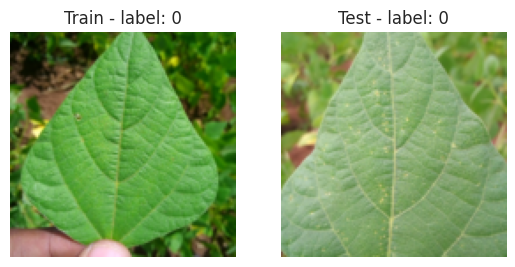

In [42]:

# imagem do conjunto de treino
plt.subplot(1, 2, 1)
img_tensor, label = train_ds[0]
img = img_tensor.permute(1, 2, 0)
plt.imshow(img)
plt.title(f'Train - label: {label}')
plt.grid(False)
plt.axis('off')

# imagem do conjunto de teste
plt.subplot(1, 2, 2)
img_tensor, label = test_ds[0]
img = img_tensor.permute(1, 2, 0)
plt.imshow(img)
plt.title(f'Test - label: {label}')
plt.grid(False)
plt.axis('off')


Use os datasets para criar  `dataloaders` de treino e teste. Lembre-se de aplicar `shuffle` no dataset de treino e de definir o tamanho dos batches (64 é uma boa escolha).

In [43]:
# resposta
from torch.utils.data import DataLoader

batch_size = 64
shuffle = True

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=shuffle)

A célula abaixo mostra as dimensões de um batch.

In [44]:
i = iter(train_loader)
imgs, labels = next(i)
imgs.shape

torch.Size([64, 3, 128, 128])

Defina a arquitetura da rede neural usando `nn.Sequential`. Vamos começar com uma operação `nn.Flatten` para transformar a imagem em um vetor. Em seguida, use as operações `nn.Linear` e `nn.ReLU` defina três camadas com função de ativação ReLU, sendo que as duas primeiras são camadas ocultas e a última é uma camada de classificação. 

- A primeira camada de receber como entrada um vetor de tamanho $128 \times 128 \times 3$ (imagens possuem 128 linhas, 128 colunas e 3 canais).
- A última camada deve ter tantos neurônios quanto o número de classes (3 no nosso caso).
- Escolha tamanhos quaisquer para as camadas intermediárias e ajuste depois com base na evolução do treinamento. 

In [57]:
# resposta
import torch.nn as nn

n_classes = 3
n_ins = 128*128*3
n_hidden = 128
learning_rate = 5e-3

net = nn.Sequential(
    nn.Flatten(),

    nn.Linear(n_ins, n_hidden),
    nn.ReLU(),

    nn.Linear(n_hidden, n_hidden),
    nn.ReLU(),

    nn.Linear(n_hidden, n_classes)
)

net

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=49152, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=3, bias=True)
)

Defina a função de perda como a entropia cruzada (`nn.CrossEntropyLoss`).

In [58]:
# resposta

criterion = nn.CrossEntropyLoss()

Crie o otimizador `Adam` com learning rate de `5e-4` (este valor equivale a $5 \times 10^{-4}$ ou $0.0004$).

In [59]:
# resposta
import torch.optim as optim

optimizer = optim.Adam(net.parameters(), learning_rate)

Implemente a função `train_loop` que recebe como entrada o dataloader de treino e o modelo e  implementar uma época de treinamento. A função deve iterar sobre os batches gerados pelo dataloader e, para cada batch:

- zerar os gradientes usando `optimizer.zero_grad()`, 
- usar as imagens como entrada para o modelo e obter predições para as classes
- calcular o erro das predições usando a função de perda e as saídas esperadas
- calcular os gradientes 
- atualizar os pesos usando `optimizer.step()`. 

Para que possamos acompanhar como as métricas estão variando ao longo do treinamento, a função deve retornar duas listas contendo as classes preditas pela rede neural e as classes esperadas para todas as amostras do dataset de treino. 

In [60]:
# resposta

def train_loop(train_loader, net):
    all_preds = []
    all_labels = []

    # itera sobre todos os batches do dataloader
    for batch in train_loader:
        # separa entadas e saídas do batch; data é uma lista contendo [inputs, labels]
        imgs, labels = batch
        # zero the parameter gradients
        optimizer.zero_grad()
        # forward
        outputs = net(imgs)
        # calcula loss
        loss = criterion(outputs, labels)
        # calcula gradientes
        loss.backward()
        # atualiza parâmetros com descida do gradiente
        optimizer.step()

        # recupera as classes preditas pelo modelo como sendo aquelas
        # com maior logits ("probabilidade" antes do softmax)
        pred_classes = np.argmax(outputs.detach().numpy(), axis=-1)

        # salva classes preditas e verdadeiras em suas respectivas listas
        all_preds.extend(list(pred_classes))
        all_labels.extend(labels)

    return all_labels, all_preds

Implemente a função `eval_loop` que recebe como entrada o dataloader de teste e o modelo e itera sobre os batches de teste prevendo as classes para cada imagem. Vamos usar estas informações junto com as classes esperadas para calcular como as métricas de performance estão mudando neste conjunto ao longo do treino. 

In [61]:
# resposta

def eval_loop(loader, net):
    all_preds = []
    all_labels = []

    # inicie um bloco no_grad dado que não precisamos calcular gradientes durante a avaliação
    with torch.no_grad():
        # itera sobre os batches de teste
        for batch in loader:
            # separa imagens e labels
            imgs, labels = batch
            # passa imagens pela rede neural para obter predições
            outputs = net(imgs)
            # obtém as classes como aquelas com maior valor na última camada
            outputs = np.argmax(outputs.numpy(), axis=-1)

            # adicione classes verdadeiras e preditas nas respectivas listas
            all_labels.extend(labels)
            all_preds.extend(list(outputs))

    return all_labels, all_preds

A célula abaixo itera por um número de épocas e usa as funções acima para treinar e avaliar o modelo. A cada época, os valores de acurácia de treino e teste são exibidos na tela e armazenados em uma variável history para visualização posterior. A função `accuracy_score` da biblioteca `scikit-learn` é utilizada para calcular a acurácia.

**IMPORTANTE**: Esta célula vai demorar um pouco para rodar. Enquanto está implementando, pode ser uma boa rodar com um subconjunto dos dados de treino e teste. 

In [62]:
from sklearn.metrics import accuracy_score

N_EPOCHS = 20

history = []

for epoch in range(N_EPOCHS):  # loop over the dataset multiple times
    true, pred = train_loop(train_loader, net)
    train_acc = accuracy_score(true, pred)

    true, pred = eval_loop(test_loader, net)
    test_acc = accuracy_score(true, pred)

    history.append([train_acc, test_acc])
    print(f"Epoch {epoch} Train acc: {train_acc:.2f} Test acc: {test_acc:.2f} ")



Epoch 0 Train acc: 0.37 Test acc: 0.33 
Epoch 1 Train acc: 0.35 Test acc: 0.33 
Epoch 2 Train acc: 0.43 Test acc: 0.53 
Epoch 3 Train acc: 0.52 Test acc: 0.47 
Epoch 4 Train acc: 0.56 Test acc: 0.57 
Epoch 5 Train acc: 0.56 Test acc: 0.63 
Epoch 6 Train acc: 0.64 Test acc: 0.65 
Epoch 7 Train acc: 0.65 Test acc: 0.69 
Epoch 8 Train acc: 0.65 Test acc: 0.62 
Epoch 9 Train acc: 0.67 Test acc: 0.58 
Epoch 10 Train acc: 0.61 Test acc: 0.70 
Epoch 11 Train acc: 0.70 Test acc: 0.66 
Epoch 12 Train acc: 0.65 Test acc: 0.70 
Epoch 13 Train acc: 0.70 Test acc: 0.70 
Epoch 14 Train acc: 0.67 Test acc: 0.59 
Epoch 15 Train acc: 0.69 Test acc: 0.66 
Epoch 16 Train acc: 0.74 Test acc: 0.71 
Epoch 17 Train acc: 0.75 Test acc: 0.74 
Epoch 18 Train acc: 0.79 Test acc: 0.68 
Epoch 19 Train acc: 0.74 Test acc: 0.71 


A célula abaixo exibe curvas comparando a acurácia de treino e teste ao longo das épocas. Analisando a curva, avalie se aconteceu underfitting, overfitting ou se o treinamento foi saudável. Veja como a curva muda ao ajustar hiperparâmetros como o número de camadas, número de neurônios por camada e learning rate.  Verifique que: 

- aumentar muito a learning rate torna o treinamento instável.
- reduzir muito a learning rate faz com que o aprendizado seja lento.
- reduzir muito a quantidade de parâmetros causa underfitting.
- aumentar muito a quantidade de parâmetros causa overfitting.

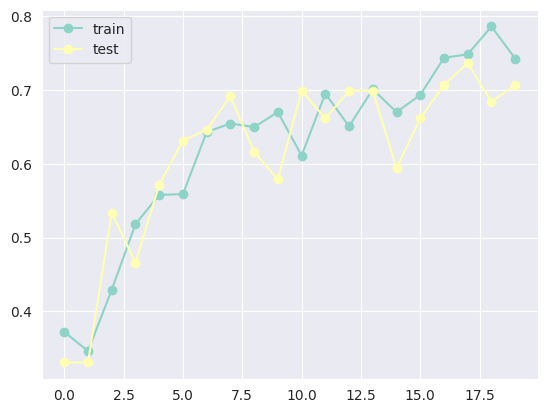

In [63]:
history = np.array(history)

plt.plot(history[:, 0], '-o')
plt.plot(history[:, 1], '-o')
plt.legend(['train', 'test'])


Use a função `classification_report` para avaliar a precisão, revocação e o f1-score para as classes no conjunto de teste. Avalie se os valores estão satisfatórios ou se o aprendizado não foi adequado para alguma classe.

In [64]:
from sklearn.metrics import classification_report

true, pred = eval_loop(test_loader, net)

# mostra o classification report na tela
print(classification_report(true, pred))

              precision    recall  f1-score   support

           0       0.82      0.73      0.77        44
           1       0.76      0.59      0.67        44
           2       0.60      0.80      0.69        45

    accuracy                           0.71       133
   macro avg       0.73      0.71      0.71       133
weighted avg       0.73      0.71      0.71       133



A célula abaixo exibe a matriz de confusão para o conjunto de teste.

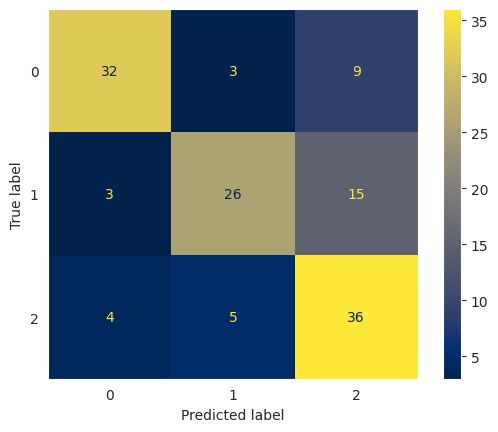

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true, pred = eval_loop(test_loader, net)
cm = confusion_matrix(true, pred, labels=list(range(3)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(3)))
disp.plot(cmap='cividis')

plt.grid(False)
plt.show()


A célula abaixo faz uma análise qualitativa mostrando imagens de exemplo, as classes preditas e esperadas.

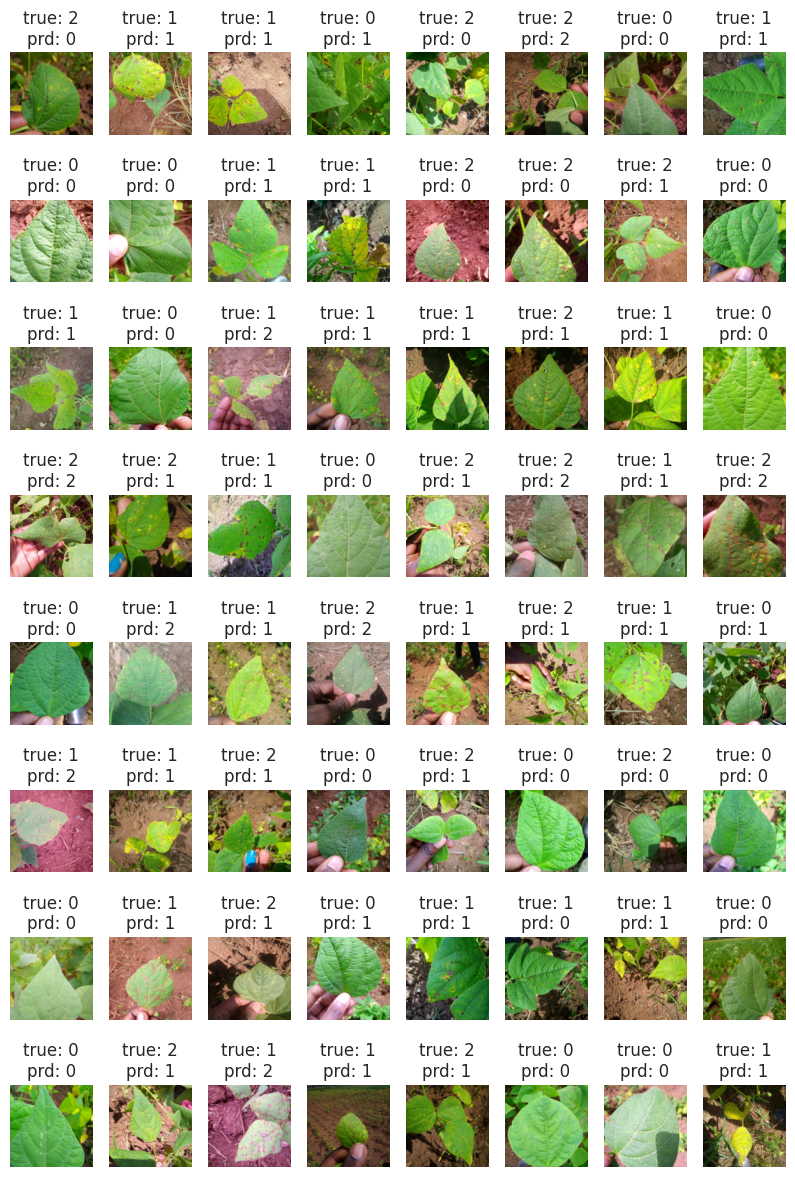

In [56]:
# seleciona um batch de teste
dataiter = iter(test_loader)
images, labels = next(dataiter)

# passa as imagens pela rede
with torch.no_grad():
    prd = net(images).numpy()

# obtém as classes preditas
prd = np.argmax(prd, axis=-1)

# mostra as imagens e as respectivas classes preditas e reais
plt.close("all")
plt.figure(figsize=(10, 15))

n = len(images)
grid_size = int(np.ceil(np.sqrt(n)))
for idx in range(n):
    plt.subplot(grid_size, grid_size, idx + 1)
    img = images[idx].numpy()
    # muda do formato [channels, rows, cols] do torch para [rows, cols, channels]
    img = np.transpose(img, (1, 2, 0))
    plt.imshow(img)
    plt.grid(False)
    plt.axis("off")
    title = f"true: {labels[idx].numpy()}"
    title += f"\nprd: {prd[idx]}"
    plt.title(title)
